# Web Scraping

## Objetivo

Nosso objetivo é encontrar algum site para ~~roubarmos~~ extrairmos informações e criarmos um banco de dados. *(com muito respeito)*

![image.png](attachment:da871c29-5c43-41d8-a4fc-cb3901b5e135.png)

## Encontra a Vítima Perfeita

Nossa principal ferramenta nesse momento é o **"Ver Código Fonte"** do navegador.

### Sites Difíceis
- **Javascript na página** ([UOL Política](https://noticias.uol.com.br/politica/))
- **Páginas com "ver mais"** ([G1 Política](https://g1.globo.com/politica/))

Para lidar com esses casos, precisamos usar uma ferramenta chamada **Selenium**.

### Sites Fáceis
- **Páginas em HTML simples** ou com **URL editável** ([Senado Notícias](https://www12.senado.leg.br/noticias/temas/politica/pagina/1))

**Encontramos nossa vítima!**


## Arma do crime

#### **`requests`**
- Biblioteca utilizada para **fazer requisições HTTP**.
- Permite acessar páginas web e obter o conteúdo delas, como HTML, JSON ou arquivos de texto.
- Fundamental para capturar o código-fonte de uma página para análise.

#### **`BeautifulSoup`** (do pacote `bs4`)
- Biblioteca usada para **analisar e manipular documentos HTML ou XML**.
- Facilita a extração de informações específicas, como títulos, links ou tabelas, a partir do conteúdo HTML obtido.

### Fluxo básico:
1. Utilize `requests` para fazer a requisição e capturar o conteúdo HTML da página.
2. Use `BeautifulSoup` para analisar o HTML e extrair os dados que deseja.


##  Capturando o HTML da Vítima

![image.png](attachment:10d9c551-3a46-428f-a664-a3ae522b97ed.png)

In [91]:
import requests
from bs4 import BeautifulSoup

In [92]:
# URL da vítima
url = "https://www.agenciaminas.mg.gov.br/noticias?page=1&tema=esportes&territorio="

# Cabeçalho para simular um navegador
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

In [93]:
response = requests.get(url, headers=headers)
response
# <Response [200]> -> requisição foi bem-sucedida

<Response [200]>

In [94]:
response.text

'<!DOCTYPE html>\n<html dir="ltr" xml:lang="pt-br" lang="pt-br" xmlns="http://www.w3.org/1999/xhtml" xmlns:fb="http://www.facebook.com/2008/fbml" itemscope itemtype="http://schema.org/">\n<head>\n  <link rel="shortcut icon" type="image/x-icon" href="/assets/favicon-ff67004ef63143778f63114d3e89a222ac5ece29230ef719706855c99f8b02f4.ico" />\n  <link rel="stylesheet" media="all" href="/assets/application-cba39f7486a5bedb9e50b106fb2d54e0693a506c6ac4582bde60e61797f5da1b.css" data-turbolinks-track="true" />\n  <title>Agência Minas Gerais | Notícias</title>\n<meta name="description" content="Acompanhe todas as notícias oficiais do Governo de Minas Gerais relacionadas aos temas de interesse da população." />\n<meta name="keywords" content="agência minas gerais, governo estadual, estado, notícias, agropecuária, ciência e tecnologia, cultura, defesa social, desenvolvimento agrário, desenvolvimento econômico, direitos humanos, educação, esportes, fazenda, gestão, governo, infraestrutura, meio ambie

In [95]:
soup = BeautifulSoup(response.text, "html.parser")

In [96]:
soup

<!DOCTYPE html>

<html dir="ltr" itemscope="" itemtype="http://schema.org/" lang="pt-br" xml:lang="pt-br" xmlns="http://www.w3.org/1999/xhtml" xmlns:fb="http://www.facebook.com/2008/fbml">
<head>
<link href="/assets/favicon-ff67004ef63143778f63114d3e89a222ac5ece29230ef719706855c99f8b02f4.ico" rel="shortcut icon" type="image/x-icon"/>
<link data-turbolinks-track="true" href="/assets/application-cba39f7486a5bedb9e50b106fb2d54e0693a506c6ac4582bde60e61797f5da1b.css" media="all" rel="stylesheet"/>
<title>Agência Minas Gerais | Notícias</title>
<meta content="Acompanhe todas as notícias oficiais do Governo de Minas Gerais relacionadas aos temas de interesse da população." name="description"/>
<meta content="agência minas gerais, governo estadual, estado, notícias, agropecuária, ciência e tecnologia, cultura, defesa social, desenvolvimento agrário, desenvolvimento econômico, direitos humanos, educação, esportes, fazenda, gestão, governo, infraestrutura, meio ambiente, saúde, social, trabalho 

In [97]:
# Exibe o html como texto
print(soup.get_text())






Agência Minas Gerais | Notícias












































Agência Minas Gerais



Abrir e fechar menu






fonte
A
A

contraste









buscar










fonte
A
A
contraste



Agência Minas Gerais




notícias

Últimas Notícias
Arquivo: notícias de 2005-2015
Arquivo: notícias de 2015-2018


multimídia

Áudios
Vídeos
Fotos


programe-se

governador

Inicial
Agenda oficial
Áudios
Vídeos
Fotos


Sala de Imprensa
Sites do Governo
Serviços
contato
















buscar





Últimas Notícias


Acessar filtro de busca


Filtrar por:



Governador

Governador






 Escolha o tema
TemasAcordo do Rio Doce
Agropecuária
Bate-Papo com o Governador
Brumadinho
Ciência e Tecnologia
Coronavírus
Cultura
Defesa Civil
Desenvolvimento Econômico
Dia da Mulher 
Direitos Humanos
Educação
Ensino Superior
Esportes
Fazenda
Gestão
Governador
Governo
Infraestrutura
Meio Ambiente
Minas Consciente
Pesquisa
Previdência
Publicidade
Recupera Minas
Reforma da Previdência
Saúde
Segurança
Servi

## Procurando uma brecha

![image.png](attachment:4711a469-f85a-407c-a78e-0b5153a55c56.png)

As Notícias Seguem o Seguinte Padrão:

```html
<div id="textoMateria">
    <h3>Todas matérias</h3>
    <ol class="list-unstyled lista-resultados">
        <li>
            <p>
                <span class="glyphicon glyphicon-list-alt"></span>
                <a href="/noticias/materias/2024/12/13/cdh-apoia-criacao-da-frente-mista-de-combate-a-violencia-politica-de-genero">
                    CDH apoia criação da Frente Mista de Combate à Violência Política de Gênero
                </a>
                <small class="text-muted">
                    13/12/2024 15h11
                </small>
            </p>
        </li>
    </ol>
</div>


	<section class="row / padding-y-2">
		<a href="/noticia/igarape-inaugura-segundo-centro-esportivo-com-recursos-do-acordo-de-brumadinho" class="link-container">
			<div class="col-auto col-xs-5 col-md-3 / margin-xs-bottom-1 margin-sm-bottom-0">
				<div class="image-container unveil">
					<img class="img-responsive" data-src="/system/news/images/000/129/168/thumb/WhatsApp_Image_2026-02-21_at_14.20.03.jpeg?1772042103" src="/assets/unveil-8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca.gif" alt="Unveil 8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca" />
				</div>
			</div>
		</a>
			<div class="col-xxs col-xs-7 col-md-9">
				<div class="margin-bottom-1 / hidden-xs">
					<a class="btn-tema bg-infraestrutura / margin-right-1" href="/noticias?tema=infraestrutura">Infraestrutura</a>
					<a class="btn-tema bg-governo / margin-right-1" href="/noticias?tema=governo">Governo</a>
					<a class="btn-tema bg-gestao / margin-right-1" href="/noticias?tema=gestao">Gestão</a>
					<a class="btn-tema bg-esportes / margin-right-1" href="/noticias?tema=esportes">Esportes</a>
					<a class="btn-tema bg-brumadinho / margin-right-1" href="/noticias?tema=brumadinho">Brumadinho</a>
				</div>
				<a href="/noticia/igarape-inaugura-segundo-centro-esportivo-com-recursos-do-acordo-de-brumadinho" class="link-container">
					<time datetime="2015-07-08" pubdate="2015-07-08" class="text-date text-date-1 block margin-bottom-1">
						<span>Qua 25 fevereiro</span>
						<span class="hidden-xs">
							<span class="line-vertical line-vertical-2"></span>
							<span>15:00</span>
							<span class="line-vertical line-vertical-2" style='display:none;'></span>
							<span style='display:none;'>atualizado em 15:10</span>
						</span>
					</time>
					<h1 class="text-title-2 color-darken-9 / hidden-xs hidden-sm"> Igarapé inaugura segundo centro esportivo com recursos do Acordo de Brumadinho </h1>
				</a>
			</div>
			<div class="col-xxs col-xs-7  /  margin-sm-top-1 / visible-xs visible-sm ">
				<a href="/noticia/igarape-inaugura-segundo-centro-esportivo-com-recursos-do-acordo-de-brumadinho" class="link-container">
					<h1 class="text-title-2 margin-bottom-0 color-darken-9"> Igarapé inaugura segundo centro esportivo com recursos do Acordo de Brumadinho </h1>
				</a>
			</div>
	</section>


In [98]:
# Localizando o bloco todas as matérias (blocknews)
bloco_noticias = soup.find("main", id="blocknews")
bloco_noticias

<main id="blocknews">
<section class="row / padding-y-2">
<a class="link-container" href="/noticia/governo-de-minas-inaugura-quadra-poliesportiva-em-andradas-e-fortalece-infraestrutura-escolar">
<div class="col-auto col-xs-5 col-md-3 / margin-xs-bottom-1 margin-sm-bottom-0">
<div class="image-container unveil">
<img alt="Unveil 8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca" class="img-responsive" data-src="/system/news/images/000/129/656/thumb/NTF_3196.JPG?1775942454" src="/assets/unveil-8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca.gif"/>
</div>
</div>
</a>
<div class="col-xxs col-xs-7 col-md-9">
<div class="margin-bottom-1 / hidden-xs">
<a class="btn-tema bg-governo / margin-right-1" href="/noticias?tema=governo">Governo</a>
<a class="btn-tema bg-esportes / margin-right-1" href="/noticias?tema=esportes">Esportes</a>
<a class="btn-tema bg-educacao / margin-right-1" href="/noticias?tema=educacao">Educação</a>
<a class="btn-tema bg-governador / marg

In [99]:
secoes = bloco_noticias.find_all("section", class_=lambda c: c and "padding-y-2" in c)
secoes

[<section class="row / padding-y-2">
 <a class="link-container" href="/noticia/governo-de-minas-inaugura-quadra-poliesportiva-em-andradas-e-fortalece-infraestrutura-escolar">
 <div class="col-auto col-xs-5 col-md-3 / margin-xs-bottom-1 margin-sm-bottom-0">
 <div class="image-container unveil">
 <img alt="Unveil 8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca" class="img-responsive" data-src="/system/news/images/000/129/656/thumb/NTF_3196.JPG?1775942454" src="/assets/unveil-8a21a6f614db065bb1ca2c21a5c803aede783f93e5277febbd47f37d9dbae4ca.gif"/>
 </div>
 </div>
 </a>
 <div class="col-xxs col-xs-7 col-md-9">
 <div class="margin-bottom-1 / hidden-xs">
 <a class="btn-tema bg-governo / margin-right-1" href="/noticias?tema=governo">Governo</a>
 <a class="btn-tema bg-esportes / margin-right-1" href="/noticias?tema=esportes">Esportes</a>
 <a class="btn-tema bg-educacao / margin-right-1" href="/noticias?tema=educacao">Educação</a>
 <a class="btn-tema bg-governador / margin-right

In [100]:
print(f"{len(secoes)} notícias encontradas\n")


10 notícias encontradas



**O elemento \<div\> é uma tag HTML que representa uma divisão ou contêiner genérico dentro de uma página web.**

In [101]:
# "/noticia/estudantes-da-rede-estadual-conquistam-o-1-lugar-no-campeonato-mundial-de-jiu-jitsu"

In [102]:
# extraindo apenas links de notícias (sem duplicatas e sem links de tema)
BASE = "https://www.agenciaminas.mg.gov.br"

links = list(dict.fromkeys(
    BASE + a['href'] for a in bloco_noticias.find_all('a', href=True)
    if a['href'].startswith('/noticia/')
))

# Exibindo os links extraídos
for link in links:
    print(link)

https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-inaugura-quadra-poliesportiva-em-andradas-e-fortalece-infraestrutura-escolar
https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-vistoria-obras-de-revitalizacao-de-ginasio-poliesportivo-em-pocos-de-caldas
https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-vistoria-instalacoes-do-programa-minas-urbano-em-ipatinga
https://www.agenciaminas.mg.gov.br/noticia/igarape-inaugura-segundo-centro-esportivo-com-recursos-do-acordo-de-brumadinho
https://www.agenciaminas.mg.gov.br/noticia/governo-do-estado-lanca-3-campeonato-mineiro-de-futebol-das-comunidades-terapeuticas
https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-abre-inscricoes-do-jemg-2026-para-municipios-mineiros
https://www.agenciaminas.mg.gov.br/noticia/premio-do-esporte-mineiro-reconhece-talentos-e-celebra-avancos-historicos-em-2025
https://www.agenciaminas.mg.gov.br/noticia/premio-do-esporte-mineiro-chega-a-9-edicao-e-celebra-destaques-esportivos-em-

**O que significa `'a', href=True`?**

- **`'a'`**: Refere-se à tag `<a>` em HTML, que é usada para criar links.
- **`href=True`**: Filtra apenas as tags `<a>` que possuem o atributo `href` definido, ou seja, que realmente apontam para algum link.

Essa combinação é utilizada para identificar e extrair apenas os links válidos dentro de uma página HTML.



## Acessando os bens

![image.png](attachment:b1dcc6f4-eec6-487c-b2b7-15f94b7846c5.png)


Conseguimos um pedaço do link para acessar as notícias, o link completo é algo da forma
https://www12.senado.leg.br + {link encontrado no passo anterior}

Vamos acessar as notícias agora!

In [103]:
# primeira notícia
full_url = links[0]
response = requests.get(full_url, headers=headers)

print(full_url)


https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-inaugura-quadra-poliesportiva-em-andradas-e-fortalece-infraestrutura-escolar


In [104]:
soup = BeautifulSoup(response.text, "html.parser")

In [105]:
soup

<!DOCTYPE html>

<html dir="ltr" itemscope="" itemtype="http://schema.org/" lang="pt-br" xml:lang="pt-br" xmlns="http://www.w3.org/1999/xhtml" xmlns:fb="http://www.facebook.com/2008/fbml">
<head>
<link href="/assets/favicon-ff67004ef63143778f63114d3e89a222ac5ece29230ef719706855c99f8b02f4.ico" rel="shortcut icon" type="image/x-icon"/>
<link data-turbolinks-track="true" href="/assets/application-cba39f7486a5bedb9e50b106fb2d54e0693a506c6ac4582bde60e61797f5da1b.css" media="all" rel="stylesheet"/>
<title>Agência Minas Gerais | Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar</title>
<meta content="O governador Mateus Simões inaugurou, nessa sexta-feira (10/4), a quadra poliesportiva Rita Aparecida Carvalho Giaretta, na Escola Municipal..." name="description"/>
<meta content="governo, de, minas, inaugura, quadra, poliesportiva, em, andradas, e, fortalece, infraestrutura, escolar" name="keywords"/>
<meta content="Governo de Minas inaugura quadra po

In [106]:
print(soup.get_text(separator="\n").strip())

Agência Minas Gerais | Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar


























































































Agência Minas Gerais








Abrir e fechar menu














fonte


A


A




contraste




















buscar






















fonte


A


A


contraste








Agência Minas Gerais










notícias




Últimas Notícias


Arquivo: notícias de 2005-2015


Arquivo: notícias de 2015-2018






multimídia




Áudios


Vídeos


Fotos






programe-se




governador




Inicial


Agenda oficial


Áudios


Vídeos


Fotos






Sala de Imprensa


Sites do Governo


Serviços


contato


































buscar


















Governo


Esportes


Educação


Governador








download



















Sáb 11 abril 2026




18:20




atualizado em Sáb 11 abril 2026 18:20




Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutu

A página de cada notícia contém `<meta>` tags com informações estruturadas:

```html
<meta property="og:title" content="Título da notícia" />
<meta name="description" property="og:description" content="Resumo..." />
<meta property="og:image" content="https://.../imagem.jpg" />
<meta property="article:published_time" content="2026-03-30T15:10:00-03:00" />
```

Além disso, os **temas** ficam em botões `btn-tema`.

In [107]:
# Extraindo o título
title = soup.find("meta", property="og:title")["content"]

# Extraindo a descrição
description = soup.find("meta", attrs={"name": "description"})["content"]

# Extraindo a data de publicação
time_tag = soup.find("time", datetime=True)
date_str = time_tag["datetime"] if time_tag else None

# Extraindo os temas (botões btn-tema), sem duplicatas
temas = list(dict.fromkeys(
    a.get_text(strip=True)
    for a in soup.find_all("a", class_=lambda c: c and "btn-tema" in c)
))

# Extraindo a imagem
img = soup.find("meta", property="og:image")["content"]

# Extraindo o texto completo da notícia (<article class="clear">)
# Limpeza do texto: pegar só a partir do título/parágrafo real
article = soup.find("article", class_="clear")
if article:
    # Remove tags de script/style que possam estar dentro
    for tag in article.find_all(["script", "style", "figure"]):
        tag.decompose()
    texto = article.get_text(separator="\n").strip()

print("Título:", title)
print("Descrição:", description)
print("Temas:", temas)
print("Data:", date_str)
print("Imagem:", img)
print("Texto (primeiras 200 chars):", texto[:200])



Título: Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar
Descrição: O governador Mateus Simões inaugurou, nessa sexta-feira (10/4), a quadra poliesportiva Rita Aparecida Carvalho Giaretta, na Escola Municipal...
Temas: ['Governo', 'Esportes', 'Educação', 'Governador']
Data: 2026-04-11 18:20:00 -0300
Imagem: https://www.agenciaminas.mg.gov.br/system/news/images/000/129/656/original/NTF_3196.JPG?1775942454
Texto (primeiras 200 chars): Sáb 11 abril 2026




18:20




atualizado em Sáb 11 abril 2026 18:20




Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar


Novo espaço amplia oportunidad


In [108]:
informacoes = {
    "url": full_url,
    "titulo": title,
    "descricao": description,
    "temas": temas,
    "imagem": img,
    "data": date_str,
    "texto": texto,
}

informacoes


{'url': 'https://www.agenciaminas.mg.gov.br/noticia/governo-de-minas-inaugura-quadra-poliesportiva-em-andradas-e-fortalece-infraestrutura-escolar',
 'titulo': 'Governo de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar',
 'descricao': 'O governador Mateus Simões inaugurou, nessa sexta-feira (10/4), a quadra poliesportiva Rita Aparecida Carvalho Giaretta, na Escola Municipal...',
 'temas': ['Governo', 'Esportes', 'Educação', 'Governador'],
 'imagem': 'https://www.agenciaminas.mg.gov.br/system/news/images/000/129/656/original/NTF_3196.JPG?1775942454',
 'data': '2026-04-11 18:20:00 -0300',
 'texto': 'Sáb 11 abril 2026\n\n\n\n\n18:20\n\n\n\n\natualizado em Sáb 11 abril 2026 18:20\n\n\n\n\nGoverno de Minas inaugura quadra poliesportiva em Andradas e fortalece infraestrutura escolar\n\n\nNovo espaço amplia oportunidades para prática esportiva e atividades pedagógicas na rede municipal\n\n\n\n\n\n\n\n\n\n\n\n\nKaroline Barreto / Imprensa MG\n\n\n\n\n\n\n\n\n

## PERDEU!!!

![image.png](attachment:ef4abcbb-c9d2-4108-aa2d-b586b85a975a.png)

Agora vamos ~~roubar~~ extrair o máximo de coisas que conseguirmos sem deixar (muitas) evidências.

In [109]:
import time
import random

In [110]:
response_pg1 = requests.get(
    "https://www.agenciaminas.mg.gov.br/noticias?page=1&tema=esportes",
    headers=headers
)
soup_pg1 = BeautifulSoup(response_pg1.text, "html.parser")

paginacao = soup_pg1.find("div", class_="pagination")
ultima_pagina = max(
    int(a.get_text()) for a in paginacao.find_all("a")
    if a.get_text().strip().isdigit()
)
print(f"Total de páginas encontradas: {ultima_pagina}")

Total de páginas encontradas: 33


In [111]:
numero_paginas = 33

links_noticias = []

for p in range(1, numero_paginas + 1):
    url = f"https://www.agenciaminas.mg.gov.br/noticias?page={p}&tema=esportes"
    response = requests.get(url, headers=headers)

    print(p, response)

    soup_p = BeautifulSoup(response.text, "html.parser")
    bloco = soup_p.find("main", id="blocknews")

    if bloco:
        novos_links = list(dict.fromkeys(
            BASE + a["href"] for a in bloco.find_all("a", href=True)
            if a["href"].startswith("/noticia/")
        ))
        links_noticias += novos_links

    tempo_espera = random.uniform(0.3, 0.8)
    time.sleep(tempo_espera)

print(f"\nTotal de links coletados: {len(links_noticias)}")

1 <Response [200]>
2 <Response [200]>
3 <Response [200]>
4 <Response [200]>
5 <Response [200]>
6 <Response [200]>
7 <Response [200]>
8 <Response [200]>
9 <Response [200]>
10 <Response [200]>
11 <Response [200]>
12 <Response [200]>
13 <Response [200]>
14 <Response [200]>
15 <Response [200]>
16 <Response [200]>
17 <Response [200]>
18 <Response [200]>
19 <Response [200]>
20 <Response [200]>
21 <Response [200]>
22 <Response [200]>
23 <Response [200]>
24 <Response [200]>
25 <Response [200]>
26 <Response [200]>
27 <Response [200]>
28 <Response [200]>
29 <Response [200]>
30 <Response [200]>
31 <Response [200]>
32 <Response [200]>
33 <Response [200]>

Total de links coletados: 323


In [112]:
len(links_noticias)

323

In [113]:
import json
import pathlib

data_dir = pathlib.Path("data_minas")
data_dir.mkdir(exist_ok=True)

for i, full_url in enumerate(links_noticias):
    response = requests.get(full_url, headers=headers)
    soup_n = BeautifulSoup(response.text, "html.parser")

    title = soup_n.find("meta", property="og:title")
    title = title["content"] if title else None

    description = soup_n.find("meta", attrs={"name": "description"})
    description = description["content"] if description else None

    date = soup_n.find("meta", property="article:published_time")
    date = date["content"] if date else None

    temas = list(dict.fromkeys(
        a.get_text(strip=True)
        for a in soup_n.find_all("a", class_=lambda c: c and "btn-tema" in c)
    ))

    img = soup_n.find("meta", property="og:image")
    imagem = img["content"] if img else None

    texto_div = soup_n.find("div", id="content")
    texto = texto_div.get_text(separator="\n").strip() if texto_div else ""

    informacoes = {
        "url": full_url,
        "titulo": title,
        "descricao": description,
        "temas": temas,
        "imagem": imagem, # Changed from 'img' to 'imagem'
        "data": date,     # Changed from 'date_str' to 'date'
        "texto": texto,
    }

    file_path = data_dir / f"noticia_{i}.json"
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(informacoes, f, ensure_ascii=False, indent=4)

    print(f"[{i+1}/{len(links_noticias)}] Salvo: {file_path.name}")

    tempo_espera = random.uniform(0.2, 0.6)
    time.sleep(tempo_espera)

[1/323] Salvo: noticia_0.json
[2/323] Salvo: noticia_1.json
[3/323] Salvo: noticia_2.json
[4/323] Salvo: noticia_3.json
[5/323] Salvo: noticia_4.json
[6/323] Salvo: noticia_5.json
[7/323] Salvo: noticia_6.json
[8/323] Salvo: noticia_7.json
[9/323] Salvo: noticia_8.json
[10/323] Salvo: noticia_9.json
[11/323] Salvo: noticia_10.json
[12/323] Salvo: noticia_11.json
[13/323] Salvo: noticia_12.json
[14/323] Salvo: noticia_13.json
[15/323] Salvo: noticia_14.json
[16/323] Salvo: noticia_15.json
[17/323] Salvo: noticia_16.json
[18/323] Salvo: noticia_17.json
[19/323] Salvo: noticia_18.json
[20/323] Salvo: noticia_19.json
[21/323] Salvo: noticia_20.json
[22/323] Salvo: noticia_21.json
[23/323] Salvo: noticia_22.json
[24/323] Salvo: noticia_23.json
[25/323] Salvo: noticia_24.json
[26/323] Salvo: noticia_25.json
[27/323] Salvo: noticia_26.json
[28/323] Salvo: noticia_27.json
[29/323] Salvo: noticia_28.json
[30/323] Salvo: noticia_29.json
[31/323] Salvo: noticia_30.json
[32/323] Salvo: noticia_31.

## Sequestro relâmpago

In [114]:
from joblib import Parallel, delayed

def parsear_credito(credito):
    if not credito or credito.strip() == "":
        return None, None
    credito = credito.replace("download da imagem", "").strip()
    if "/" in credito:
        partes = credito.split("/", 1)
        return partes[0].strip(), partes[1].strip()
    return None, credito.strip()

def processar_noticia(i, full_url):
    response = requests.get(full_url, headers=headers)
    soup_n = BeautifulSoup(response.text, "html.parser")

    # Título
    title = soup_n.find("meta", property="og:title")
    title = title["content"] if title else None

    # Descrição
    description = soup_n.find("meta", attrs={"name": "description"})
    description = description["content"] if description else None

    # Data
    time_tag = soup_n.find("time", datetime=True)
    date_str = time_tag["datetime"] if time_tag else None

    # Hora de atualização (texto visível do <time>)
    hora_atualizacao = time_tag.get_text(separator=" ", strip=True) if time_tag else ""

    # Temas
    temas = list(dict.fromkeys(
        a.get_text(strip=True)
        for a in soup_n.find_all("a", class_=lambda c: c and "btn-tema" in c)
    ))

    # Imagem
    img = soup_n.find("meta", property="og:image")
    imagem = img["content"] if img else None

    # Crédito da foto
    credito_tag = soup_n.find("div", class_=lambda c: c and "news-image-text" in str(c))
    credito_foto = credito_tag.get_text(strip=True) if credito_tag else ""

    # Texto (removendo tags de figura/ícone antes de extrair)
    article = soup_n.find("article", class_="clear")
    if article:
        for tag in article.find_all(["script", "style", "figure"]):
            tag.decompose()
        texto = article.get_text(separator="\n").strip()
    else:
        texto = ""

    # Subtítulo
    subtitulo_tag = soup_n.find("h2")
    subtitulo = subtitulo_tag.get_text(strip=True) if subtitulo_tag else ""

    # Número de notícias relacionadas linkadas na página
    relacionadas = soup_n.find_all("div", class_=lambda c: c and "news-last-description" in str(c))
    n_relacionadas = len(relacionadas)

    # Número de palavras do título
    n_palavras_titulo = len(title.split()) if title else 0

    fotografo, orgao_foto = parsear_credito(credito_foto)

    informacoes = {
        "url":              full_url,
        "titulo":           title,
        "subtitulo":        subtitulo,
        "descricao":        description,
        "temas":            temas,
        "imagem":           imagem,
        "fotografo":        fotografo,
        "orgao_foto":       orgao_foto,
        "data":             date_str,
        "hora_atualizacao": hora_atualizacao,
        "texto":            texto,
        "n_relacionadas":   n_relacionadas,
        "n_palavras_titulo":n_palavras_titulo,
    }

    file_path = data_dir / f"noticia_{i}.json"
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(informacoes, f, ensure_ascii=False, indent=4)

    print(f"Arquivo salvo: {file_path.name}")
    time.sleep(random.uniform(0, 0.3))

# Executa em paralelo com threads
Parallel(n_jobs=8, prefer="threads")(
    delayed(processar_noticia)(i, link) for i, link in enumerate(links_noticias)
)

Arquivo salvo: noticia_0.json
Arquivo salvo: noticia_7.json
Arquivo salvo: noticia_5.json
Arquivo salvo: noticia_1.json
Arquivo salvo: noticia_3.json
Arquivo salvo: noticia_4.json
Arquivo salvo: noticia_6.json
Arquivo salvo: noticia_2.json
Arquivo salvo: noticia_8.json
Arquivo salvo: noticia_9.json
Arquivo salvo: noticia_10.json
Arquivo salvo: noticia_12.json
Arquivo salvo: noticia_11.json
Arquivo salvo: noticia_14.json
Arquivo salvo: noticia_13.json
Arquivo salvo: noticia_15.json
Arquivo salvo: noticia_16.json
Arquivo salvo: noticia_17.json
Arquivo salvo: noticia_18.json
Arquivo salvo: noticia_19.json
Arquivo salvo: noticia_20.json
Arquivo salvo: noticia_21.json
Arquivo salvo: noticia_22.json
Arquivo salvo: noticia_23.json
Arquivo salvo: noticia_24.json
Arquivo salvo: noticia_25.json
Arquivo salvo: noticia_26.json
Arquivo salvo: noticia_27.json
Arquivo salvo: noticia_28.json
Arquivo salvo: noticia_29.json
Arquivo salvo: noticia_30.json
Arquivo salvo: noticia_31.json
Arquivo salvo: not

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

## Análise dos nossos espólios

![image.png](attachment:aee4be16-6db6-4249-b70e-f0202d6452e6.png)

In [118]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import json
import pathlib

data_dir = pathlib.Path("data_minas")
registros = []

for json_file in data_dir.rglob("*.json"):
    try:
        with json_file.open("r", encoding="utf-8") as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Skipping corrupted file: {json_file}")
        continue

    date_str = data.get("data", "")
    date = None
    if date_str:
        try:
            date = datetime.fromisoformat(date_str)
        except ValueError:
            try:
                date = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S %z")
            except ValueError:
                try:
                    date = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
                except ValueError:
                    pass

    texto = data.get("texto", "")
    temas = data.get("temas", [])

    fotografo, orgao_foto = parsear_credito(data.get("credito_foto", ""))

    registros.append({
        "titulo":            data.get("titulo", ""),
        "subtitulo":         data.get("subtitulo", ""),
        "descricao":         data.get("descricao", ""),
        "temas":             temas,
        "data":              date,
        "ano_mes":           date.strftime("%Y-%m") if date else None,
        "ano":               date.year  if date else None,
        "mes":               date.month if date else None,
        "hora":              date.hour  if date else None,
        "turno":             ("Manhã" if date and date.hour < 12 else
                              "Tarde" if date and date.hour < 18 else
                              "Noite" if date else None),
        "n_temas":           len(temas),
        "tamanho_texto":     len(texto.split()),
        "n_palavras_titulo": data.get("n_palavras_titulo", 0),
        "n_relacionadas":    data.get("n_relacionadas", 0),
        "url":               data.get("url", ""),
    })

df = pd.DataFrame(registros)

print(f"Total de notícias carregadas: {len(df)}")
print(f"Com data:  {df['data'].notna().sum()}")
print(f"Com texto: {(df['tamanho_texto'] > 0).sum()}")
df.head()

Total de notícias carregadas: 323
Com data:  323
Com texto: 323


,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,n_temas,tamanho_texto,n_palavras_titulo,n_relacionadas,url
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"[Social, Esportes]",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,2,623,16,4,https://www.agenciaminas.mg.gov.br/noticia/min...
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"[Social, Esportes]",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,2,684,12,4,https://www.agenciaminas.mg.gov.br/noticia/min...
2,Estudantes de BH vão carregar bandeiras de Bra...,"Ao todo, 26 alunos da Escola Estadual Tomás Br...",Esta terça-feira (2/7) é de expectativa para 2...,"[Educação, Esportes]",2019-07-02 17:02:00-03:00,2019-07,2019,7,17,Tarde,2,425,12,4,https://www.agenciaminas.mg.gov.br/noticia/est...
3,Governo publica edital 2019 do programa Bolsa ...,As inscrições terminam no próximo dia 12 de se...,A Secretaria de Estado de Desenvolvimento Soci...,"[Social, Esportes]",2019-08-27 14:35:00-03:00,2019-08,2019,8,14,Tarde,2,700,12,4,https://www.agenciaminas.mg.gov.br/noticia/gov...
4,Cruzeiro e Minas Arena assinam acordo mediado ...,Documento foi assinado na tarde desta sexta-fe...,O acordo comercial entre a Minas Arena e o Cru...,[Esportes],2023-04-28 18:25:00-03:00,2023-04,2023,4,18,Noite,1,463,18,4,https://www.agenciaminas.mg.gov.br/noticia/cru...


In [119]:
df.to_csv("data_minas/noticias_agencia_minas.csv", index=False, encoding="utf-8-sig")
print(f"CSV salvo com {len(df)} linhas!")

CSV salvo com 323 linhas!


In [120]:
from google.colab import files

files.download("data_minas/noticias_agencia_minas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

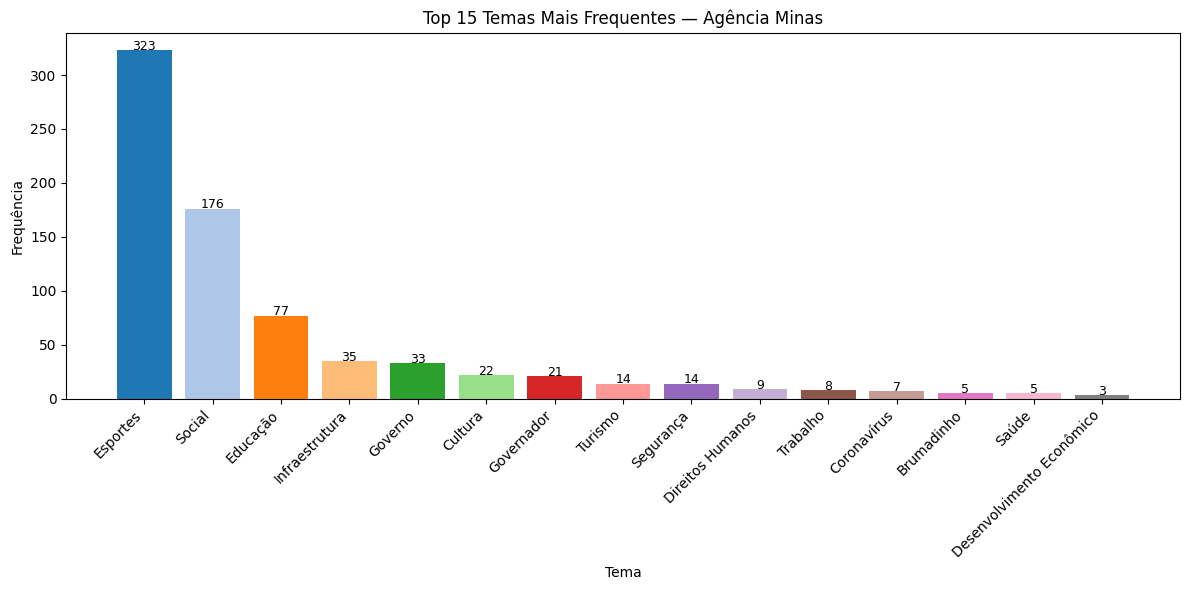

In [121]:
df_temas = df.explode("temas").dropna(subset=["temas"])
tema_counts = df_temas["temas"].value_counts().head(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(tema_counts.index, tema_counts.values,
               color=plt.cm.tab20.colors[:len(tema_counts)])
plt.xlabel("Tema")
plt.ylabel("Frequência")
plt.title("Top 15 Temas Mais Frequentes — Agência Minas")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, tema_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


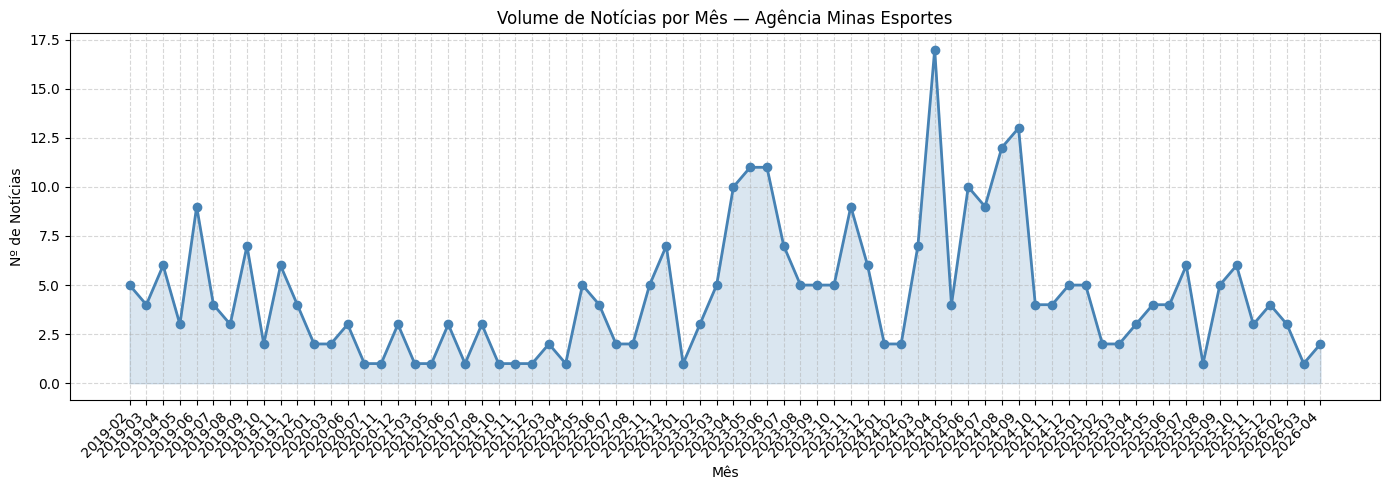

In [122]:
noticias_por_mes = df.dropna(subset=["ano_mes"]).groupby("ano_mes").size()

plt.figure(figsize=(14, 5))
plt.plot(noticias_por_mes.index, noticias_por_mes.values,
         marker="o", color="steelblue", linewidth=2)
plt.fill_between(noticias_por_mes.index, noticias_por_mes.values,
                 alpha=0.2, color="steelblue")
plt.xlabel("Mês")
plt.ylabel("Nº de Notícias")
plt.title("Volume de Notícias por Mês — Agência Minas Esportes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
